# **Optimal Airline Route Planning and Fleet Utilization in Africa**
## **Integrated notebook based on the provided PDFs and previous analyses**
### **AIMS Numerical Optimization Project**

This notebook has been reorganized so that it is:

- **clear and ordered**,
- **directly executable in Python/Jupyter**,
- **consistent with the optimization analyses already developed**, and
- **enriched with the content of the two provided PDF documents**.

The notebook now combines:
1. the **project brief on airline route planning in Africa**,
2. the **broader optimization perspective on robust distribution networks in Africa**, and
3. the **Python implementation, optimization results, and final interactive visualization** of the optimized African air transport network.

# **0. Notebook roadmap**

This notebook is organized as follows:

1. **Integrated project context from the provided PDFs**
2. **Data import and preprocessing**
3. **Data enrichment and exploratory analysis**
4. **Construction of demand, revenue, and cost proxies**
5. **Optimization model**
6. **Extraction of the optimized flight plan**
7. **Final interactive visualization of the optimized African airline network**

The final result is a notebook that can serve both as a **computational report** and as a **clear project support document**.

# **1. Integrated material from PDF 1: robust optimization in Africa**

## **Source document**
**Student Projects AIMS JAN 2026_thierry.pdf**

## **Main project idea extracted from the PDF**
The first PDF presents a project on the **robust optimization of food distribution networks under demand and transport uncertainty in Africa**.  
Its central motivation is that African logistics systems often operate under:

- **uncertain demand**,
- **long transport distances**,
- **weak infrastructure**,
- **seasonal or shock-related disruptions**, and
- **cost pressure under operational uncertainty**.

The strategic question posed in that document is:

> *Where should logistics resources be located, and how should flows be allocated, so that shortages are reduced, costs are controlled, and the system remains robust to shocks?*

## **Why this PDF is useful for the present notebook**
Even though the present notebook focuses on **airline route planning**, the first PDF provides a very useful **optimization perspective**:

- the importance of **African context and infrastructure constraints**,
- the need to balance **economic performance** with **network service quality**,
- the role of **robustness and strategic connectivity**, and
- the expectation of a **clear notebook with mathematical formulation, algorithmic choices, and final results**.

## **Practical contribution to this notebook**
Inspired by this first PDF, the present notebook does not only maximize a simple local profit measure. It also gives importance to:

- **connectivity**,
- **hub effects**,
- **strategic network coverage**, and
- a final output that is **readable, reproducible, and visually interpretable**.

# **2. Integrated material from PDF 2: airline route planning project statement**

## **Source document**
**Thierry (1)(2).pdf**

## **Project statement integrated into the notebook**
The second PDF is the direct statement of the airline optimization project. Its main elements are incorporated here as the conceptual basis of the code.

### **Available data**
The project is based on OpenFlights data:

- **airports.dat** for airport locations and metadata,
- **routes.dat** for existing route connections.

These data provide:

- airport coordinates,
- city and country information,
- existing network connections.

### **Key modeling challenge**
The PDF explicitly states that the datasets do **not** provide:

- ticket prices,
- passenger demand,
- direct revenue information.

Therefore, the optimization must rely on **economic proxies** rather than complete market data.

### **Decision variables suggested in the PDF**
The project statement recommends variables such as:

- route activation,
- flight frequency,
- optional aircraft assignment.

### **Recommended modeling choices from the PDF**
The PDF suggests:

- modeling demand as a function of **distance**, **connectivity**, and **hub centrality**,
- building a synthetic revenue model of the form  
  $$
  D_{ij} = \alpha C_i C_j e^{-\beta d_{ij}}, \qquad
  R_{ij} = \rho D_{ij} f_{ij},
  $$
- modeling operating costs using a proxy such as  
  $$
  C_{ij} = c_f d_{ij} + c_a,
  $$
- and maximizing either **profit alone** or a **multi-objective criterion** including strategic connectivity.

### **Constraints recommended in the PDF**
The project statement also highlights realistic constraints such as:

- limited fleet size,
- aircraft range constraints,
- maximum route frequency,
- minimum connectivity for underserved areas,
- regulatory or operational limits.

## **How this notebook follows the PDF**
The code below follows this logic by constructing:

1. a **demand proxy**,
2. a **revenue estimate**,
3. a **route cost proxy**,
4. an **optimization model with activation and frequency variables**, and
5. a **final map of the optimized African airline network**.

# **3. Modeling perspective adopted in this final notebook**

The two PDFs complement each other:

- the **first PDF** contributes a broader African optimization perspective centered on **robustness, logistics constraints, and stakeholder relevance**;
- the **second PDF** provides the **direct mathematical and computational framework** for airline route planning.

As a result, this notebook is structured as a **clear optimization workflow**:

- start from open aviation data,
- enrich the data with operational and economic proxies,
- formulate a realistic optimization problem,
- extract the optimized flight plan,
- and visualize the final African air network in an interpretable way.

The last section of the notebook provides an **interactive map** that is consistent with the optimization results computed above.

# **Appendix A. Extracted text from PDF 1**

<details>
<summary><b>Click to expand the integrated extract from the first PDF</b></summary>

### **Robust Optimization of Food Distribution Networks under Demand and Transport Uncertainty in Africa**

Food insecurity remains one of the most critical socio-economic challenges in Sub-Saharan Africa. Rapid population growth, climate variability, poor road infrastructure, fuel price volatility, and geopolitical instability frequently lead to food shortages, price spikes, and unequal access to basic commodities.

In many African countries, food distribution systems are characterized by:

- a small number of central warehouses (often near ports or capitals),
- long transport routes to rural and peri-urban markets,
- unreliable road networks (seasonal road closures, flooding),
- highly uncertain demand, especially during shocks.

The strategic question is:

> Where should we locate food warehouses and how should food flows be allocated so that shortages are minimized, costs are controlled, and the system remains robust to shocks?

### **Minimum deliverables**
1. Problem statement (Africa context + stakeholders + constraints + objective)  
2. Mathematical formulation (variables, objective, constraints)  
3. Solution approach (algorithm + complexity + why chosen)  
4. Python notebook (reproducible, clear plots, final results)  
5. 15-20 slide Beamer (storytelling + visuals)

</details>

# **Appendix B. Extracted text from PDF 2**

<details>
<summary><b>Click to expand the integrated extract from the second PDF</b></summary>

### **Optimal Airline Route Planning and Fleet Utilization in Africa**

#### **Available data**
- OpenFlights airports data  
- OpenFlights routes data  

These datasets provide airport locations, country/city information, and existing route connections.

#### **Important modeling note**
The datasets do **not** contain ticket prices, passenger demand, or revenues.  
Therefore, the optimization must rely on realistic economic and network proxies.

#### **Suggested decision variables**
- Route activation
- Flight frequency
- Optional aircraft assignment

#### **Suggested demand and revenue proxy**
$$
D_{ij} = \alpha C_i C_j e^{-\beta d_{ij}}, \qquad
R_{ij} = \rho D_{ij} f_{ij}
$$

#### **Suggested operating cost proxy**
$$
C_{ij} = c_f d_{ij} + c_a
$$

#### **Suggested objective**
Maximize either:

- profit only, or
- a multi-objective criterion including strategic connectivity.

#### **Suggested constraints**
- limited fleet size,
- aircraft range constraints,
- maximum route frequency,
- minimum connectivity for underserved regions,
- regulatory or operational limits.

</details>

# **4. Environment and libraries**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import folium
import pulp

# **5. Data import and preprocessing**

## **5.1 Airports data**

In [102]:
# airports  column names: source: https://openflights.org/data.php
airports_columns = [ "airport_id", "name", "city", "country", "iata", "icao", "latitude", "longitude", "altitude", "timezone", "dst", "tz_database", "type", "source"]

In [103]:
## upload openflight airports
airports = pd.read_csv(
    "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat",
    header=None,
    names=airports_columns
)

In [104]:
airports.head()

,airport_id,name,city,country,iata,icao,latitude,longitude,altitude,timezone,dst,tz_database,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


## **5.2 Routes data**

In [105]:
# routes columns
routes_columns = [
    "airline", "airline_id",
    "source_airport", "source_airport_id",
    "destination_airport", "destination_airport_id",
    "codeshare", "stops", "equipment"
]

In [106]:
## routes openflights data
routes = pd.read_csv(
    "https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat",
    header=None,
    names=routes_columns
)

In [107]:
# print the 5th rows of routes
routes.head(5)

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2














# **6. Data enrichment**

## **6.1 Aircraft reference data**

In [108]:
# Air craft
air_craft_data = pd.read_excel("https://www.faa.gov/airports/engineering/aircraft_char_database/aircraft_data")


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [109]:
air_craft_data = air_craft_data.loc[:, ~air_craft_data.columns.str.contains("^Unnamed")]
air_craft_data.head(2)

,ICAO_Code,FAA_Designator,Manufacturer,Model_FAA,Model_BADA,Physical_Class_Engine,Num_Engines,AAC,AAC_minimum,AAC_maximum,...,Two_Wake_Category_Appx_A,Two_Wake_Category_Appx_B,Rotor_Diameter_ft,SRS,LAHSO,FAA_Registry,Registration_Count,TMFS_Operations_FY24,Remarks,LastUpdate
0,A10,A10,FAIRCHILD,Fairchild A10,Fairchild A-10A,Jet,2,C,NaN,NaN,...,D,D,NaN,III,NaN,Yes,281.0,12844,NaN,NaT
1,A124,A124,ANTONOV,Antonov AN-124 Ruslan,Antonov AN-124-100,Jet,4,D,NaN,NaN,...,G,G,NaN,III,NaN,Yes,55.0,506,NaN,NaT


In [110]:
air_craft_data.loc[0:5,['ICAO_Code','Model_BADA','Model_FAA','ICAO_WTC']]

,ICAO_Code,Model_BADA,Model_FAA,ICAO_WTC
0,A10,Fairchild A-10A,Fairchild A10,Medium
1,A124,Antonov AN-124-100,Antonov AN-124 Ruslan,Heavy
2,A19N,Airbus A319 Neo,Airbus A319 Neo,Medium
3,A20N,Airbus A320-271N,Airbus A320 Neo,Medium
4,A21N,Airbus A321-251N,Airbus A321 Neo,Medium
5,A306,Airbus A300B4-622,Airbus A300 B4-600,Heavy


# **7. Overview and exploratory analysis**

In [111]:
# Check source and destination airports
routes[(routes['source_airport'] == 'AER') & (routes['destination_airport'] == 'KZN')]
routes[(routes['source_airport'] == 'KZN') & (routes['destination_airport'] == 'AER')]

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment
13,2B,410,KZN,2990,AER,2965,NaN,0,CR2


In [112]:
# Filters routes equipement == 100
routes[(routes['equipment'] == "100")]

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment
115,2L,2750,BDS,1506,ZRH,1678,NaN,0,100
116,2L,2750,BOD,1264,ZRH,1678,NaN,0,100
117,2L,2750,BRS,490,ZRH,1678,NaN,0,100
123,2L,2750,ZRH,1678,BDS,1506,NaN,0,100
124,2L,2750,ZRH,1678,BOD,1264,NaN,0,100
...,...,...,...,...,...,...,...,...,...
66378,Z9,18825,GUW,4357,URA,2916,NaN,0,100
66379,Z9,18825,TSE,2910,ALA,2908,NaN,0,100
66380,Z9,18825,TSE,2910,URA,2916,NaN,0,100
66381,Z9,18825,URA,2916,GUW,4357,NaN,0,100


In [113]:
# the number of
print("Number of airports :", airports.shape[0])
print("Number of routes :", routes.shape[0])

Number of airports : 7698
Number of routes : 67663


In [114]:
# check values count for airports_country and routes_sources_airport
airports["country"].value_counts().head(10)
routes["source_airport"].value_counts().head(10)

,count
source_airport,
ATL,915
ORD,558
PEK,535
LHR,527
CDG,524
FRA,497
LAX,492
DFW,469
JFK,456


In [115]:
# African countries all of countries
african_countries = [
    "Algeria","Angola","Benin","Botswana","Burkina Faso","Burundi",
    "Cabo Verde","Cameroon","Central African Republic","Chad","Comoros",
    "Congo (Brazzaville)","Congo (Kinshasa)","Djibouti","Egypt",
    "Equatorial Guinea","Eritrea","Eswatini","Ethiopia","Gabon",
    "Gambia","Ghana","Guinea","Guinea-Bissau","Ivory Coast","Kenya",
    "Lesotho","Liberia","Libya","Madagascar","Malawi","Mali",
    "Mauritania","Mauritius","Morocco","Mozambique","Namibia","Niger",
    "Nigeria","Rwanda","Sao Tome and Principe","Senegal","Seychelles",
    "Sierra Leone","Somalia","South Africa","South Sudan","Sudan",
    "Tanzania","Togo","Tunisia","Uganda","Zambia","Zimbabwe"
]

In [116]:
#
african_airports = airports[
    airports["country"].isin(african_countries)
].copy()

In [117]:
print("African airports:", african_airports.shape[0])

African airports: 731


In [118]:
african_airports = african_airports[~african_airports['airport_id'].isin([8816, 5627, 6826, 5613])]

In [119]:
african_airports["country"].value_counts().head()

,count
country,
South Africa,99
Congo (Kinshasa),44
Algeria,44
Madagascar,42
Kenya,34


In [120]:
african_airports.head()

,airport_id,name,city,country,iata,icao,latitude,longitude,altitude,timezone,dst,tz_database,type,source
205,207,Blida Airport,Blida,Algeria,QLD,DAAB,36.503601,2.81417,535,1,N,Africa/Algiers,airport,OurAirports
206,208,Bou Saada Airport,Bou Saada,Algeria,BUJ,DAAD,35.332500,4.20639,1506,1,N,Africa/Algiers,airport,OurAirports
207,209,Soummam Airport,Bejaja,Algeria,BJA,DAAE,36.712002,5.06992,20,1,N,Africa/Algiers,airport,OurAirports
208,210,Houari Boumediene Airport,Algier,Algeria,ALG,DAAG,36.691002,3.21541,82,1,N,Africa/Algiers,airport,OurAirports
209,211,Djanet Inedbirene Airport,Djanet,Algeria,DJG,DAAJ,24.292801,9.45244,3176,1,N,Africa/Algiers,airport,OurAirports


# **8. Data processing, transformation, and cleaning**

In [121]:
#
routes.isna().sum()

,0
airline,0
airline_id,0
source_airport,0
source_airport_id,0
destination_airport,0
destination_airport_id,0
codeshare,53066
stops,0
equipment,18


In [122]:
#
routes = routes[
    (routes["source_airport"] != "\\N") &
    (routes["destination_airport"] != "\\N")
]

In [123]:
# Transformation `_id` to numeric
routes["source_airport_id"] = pd.to_numeric(
    routes["source_airport_id"], errors="coerce"
)
routes["destination_airport_id"] = pd.to_numeric(
    routes["destination_airport_id"], errors="coerce"
)

In [124]:
#
african_iata = set(african_airports["iata"])

In [125]:
## African airports
#
african_airports = airports[
    airports["country"].isin(african_countries)
].copy()

In [126]:
#
african_airports = african_airports[~african_airports['airport_id'].isin([8816, 5627, 6826, 5613])]

## **8.1 Equipment data**

In [127]:
# Upload equiment data from avocdes.co.uk
equipments = pd.read_html("https://www.avcodes.co.uk/acrtypes.asp")[0]

In [128]:
# Show 5 first rows
equipments.head()

,IATA Code,ICAO Code,Manufacturer and Aircraft Type / Model,WTC
0,100,F100,Fokker 100,M
1,141,B461,BAe 146-100 Pax,M
2,142,B462,BAe 146-200 Pax,M
3,143,B463,BAe 146-300 Pax,M
4,146,NaN,BAe 146 all pax models,M


In [129]:
#
equipments["Manufacturer and Aircraft Type / Model"]

,Manufacturer and Aircraft Type / Model
0,Fokker 100
1,BAe 146-100 Pax
2,BAe 146-200 Pax
3,BAe 146-300 Pax
4,BAe 146 all pax models
...,...
394,Yakovlev Yak 42
395,Yakovlev Yak 40
396,Harbin Yunshuji Y12
397,Xian Yunshuji Y7


## **8.2 Estimated seats**

In [130]:
##
sheet_id = "1AsnDCk_RZ096TtIViipR-f1EiF5BFaFc"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx"
##
estimated_seats = pd.read_excel(url, engine="openpyxl")
estimated_seats = estimated_seats.loc[:, ~estimated_seats.columns.str.contains("^Unnamed")]
estimated_seats = estimated_seats.iloc[::,0:5]

In [131]:
african_airports["country"].value_counts().head()

,count
country,
South Africa,99
Congo (Kinshasa),44
Algeria,44
Madagascar,42
Kenya,34


In [132]:
# Transformation `_id` to numeric
routes["source_airport_id"] = pd.to_numeric(
    routes["source_airport_id"], errors="coerce"
)
routes["destination_airport_id"] = pd.to_numeric(
    routes["destination_airport_id"], errors="coerce"
)

In [133]:
african_routes = routes[
    (routes["source_airport"].isin(african_iata)) &
    (routes["destination_airport"].isin(african_iata))
].copy()

print("African routes :", african_routes.shape[0])

African routes : 1928


In [134]:
#
african_routes = african_routes.merge(
    african_airports[[
        "iata", "latitude", "longitude", "country", "city"
    ]],
    left_on="source_airport",
    right_on="iata",
    how="inner"
).rename(columns={
    "latitude": "source_lat",
    "longitude": "source_lon",
    "country": "source_country",
    "city": "source_city"
}).drop(columns=["iata"])

In [135]:
african_routes = african_routes.merge(
    african_airports[[
        "iata", "latitude", "longitude", "country", "city"
    ]],
    left_on="destination_airport",
    right_on="iata",
    how="inner"
).rename(columns={
    "latitude": "dest_lat",
    "longitude": "dest_lon",
    "country": "dest_country",
    "city": "dest_city"
}).drop(columns=["iata"])

In [136]:
african_routes.head()

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment,source_lat,source_lon,source_country,source_city,dest_lat,dest_lon,dest_country,dest_city
0,2J,470,ACC,248.0,OUA,246.0,NaN,0,CRJ,5.60519,-0.166786,Ghana,Accra,12.35320,-1.51242,Burkina Faso,Ouagadougou
1,2J,470,BKO,1044.0,DKR,1084.0,NaN,0,M87,12.53350,-7.949940,Mali,Bamako,14.73970,-17.49020,Senegal,Dakar
2,2J,470,BKO,1044.0,OUA,246.0,NaN,0,CRJ,12.53350,-7.949940,Mali,Bamako,12.35320,-1.51242,Burkina Faso,Ouagadougou
3,2J,470,BOY,247.0,OUA,246.0,NaN,0,CRJ,11.16010,-4.330970,Burkina Faso,Bobo-dioulasso,12.35320,-1.51242,Burkina Faso,Ouagadougou
4,2J,470,COO,245.0,LFW,298.0,NaN,0,M87,6.35723,2.384350,Benin,Cotonou,6.16561,1.25451,Togo,Lome


In [137]:
african_routes["source_country"].value_counts().head(10)

,count
source_country,
South Africa,207
Kenya,155
Algeria,100
Nigeria,97
Ethiopia,87
Egypt,72
Tanzania,67
Angola,63
Mozambique,60


In [138]:
print("African airports:", african_airports.shape[0])

African airports: 727


---
# **Decision variable function**

In [139]:
# The 'x' function will be redefined and tested later in the notebook after 'african_routes' is defined.
def x(source_airport,destination_airport):
    return int(not bool(african_routes[(african_routes['source_airport'] == source_airport) & (african_routes['destination_airport'] == destination_airport)].empty))

In [140]:
# Test
x('BDS','ZRH')

0

In [141]:
# This test will fail with a NameError because 'african_routes' is not yet defined.
# The function 'x' will be redefined and tested later in the notebook.
# x('BDS','ZRH')

# **9. Fuel and energy consumption estimation**


Knot is the unit of speed used in aviation
1 knot = 1.15 miles per hour (statute miles per hour)

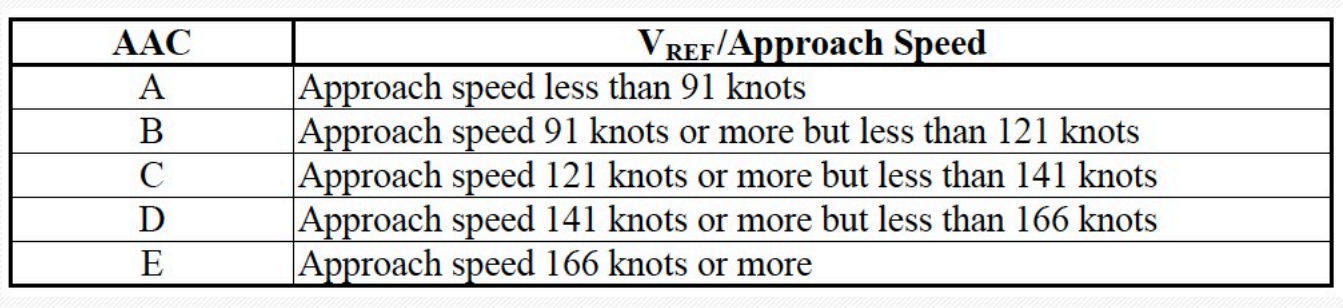

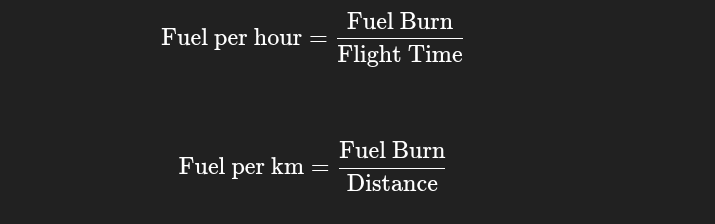


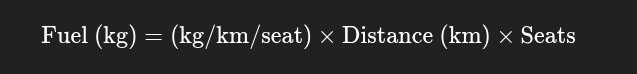


# kg fuel / km /seat = ~0,02 à 0,025 kg/km/seat

https://reposit.haw-hamburg.de/bitstream/20.500.12738/14232/1/AERO_POS_DLRK2023_FuelConsumption_2023-09-19.pdf

In [142]:
##
air_craft_data.columns

Index(['ICAO_Code', 'FAA_Designator', 'Manufacturer', 'Model_FAA',
       'Model_BADA', 'Physical_Class_Engine', 'Num_Engines', 'AAC',
       'AAC_minimum', 'AAC_maximum', 'ADG', 'TDG', 'Approach_Speed_knot',
       'Approach_Speed_minimum_knot', 'Approach_Speed_maximum_knot',
       'Wingspan_ft_without_winglets_sharklets',
       'Wingspan_ft_with_winglets_sharklets', 'Length_ft',
       'Tail_Height_at_OEW_ft', 'Wheelbase_ft', 'Cockpit_to_Main_Gear_ft',
       'Main_Gear_Width_ft', 'MTOW_lb', 'MALW_lb', 'Main_Gear_Config',
       'ICAO_WTC', 'Parking_Area_ft2', 'Class', 'FAA_Weight', 'CWT',
       'One_Half_Wake_Category', 'Two_Wake_Category_Appx_A',
       'Two_Wake_Category_Appx_B', 'Rotor_Diameter_ft', 'SRS', 'LAHSO',
       'FAA_Registry', 'Registration_Count', 'TMFS_Operations_FY24', 'Remarks',
       'LastUpdate'],
      dtype='object')

In [143]:
#


# **10. Add useful variables for modeling**

In [144]:
# Upload equiment data from avocdes.co.uk
equipments = pd.read_html("https://www.avcodes.co.uk/acrtypes.asp")[0]

In [145]:
# Show 5 first rows
equipments.head()

,IATA Code,ICAO Code,Manufacturer and Aircraft Type / Model,WTC
0,100,F100,Fokker 100,M
1,141,B461,BAe 146-100 Pax,M
2,142,B462,BAe 146-200 Pax,M
3,143,B463,BAe 146-300 Pax,M
4,146,NaN,BAe 146 all pax models,M


In [146]:
#
equipments["Manufacturer and Aircraft Type / Model"]

,Manufacturer and Aircraft Type / Model
0,Fokker 100
1,BAe 146-100 Pax
2,BAe 146-200 Pax
3,BAe 146-300 Pax
4,BAe 146 all pax models
...,...
394,Yakovlev Yak 42
395,Yakovlev Yak 40
396,Harbin Yunshuji Y12
397,Xian Yunshuji Y7


In [147]:
air_craft_data = pd.read_excel("https://www.faa.gov/airports/engineering/aircraft_char_database/aircraft_data")
air_craft_data = air_craft_data.loc[:, ~air_craft_data.columns.str.contains("^Unnamed")]
air_craft_data.head(2)

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,ICAO_Code,FAA_Designator,Manufacturer,Model_FAA,Model_BADA,Physical_Class_Engine,Num_Engines,AAC,AAC_minimum,AAC_maximum,...,Two_Wake_Category_Appx_A,Two_Wake_Category_Appx_B,Rotor_Diameter_ft,SRS,LAHSO,FAA_Registry,Registration_Count,TMFS_Operations_FY24,Remarks,LastUpdate
0,A10,A10,FAIRCHILD,Fairchild A10,Fairchild A-10A,Jet,2,C,NaN,NaN,...,D,D,NaN,III,NaN,Yes,281.0,12844,NaN,NaT
1,A124,A124,ANTONOV,Antonov AN-124 Ruslan,Antonov AN-124-100,Jet,4,D,NaN,NaN,...,G,G,NaN,III,NaN,Yes,55.0,506,NaN,NaT


In [148]:
##
sheet_id = "1AsnDCk_RZ096TtIViipR-f1EiF5BFaFc"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx"
##
estimated_seats = pd.read_excel(url, engine="openpyxl")
estimated_seats = estimated_seats.loc[:, ~estimated_seats.columns.str.contains("^Unnamed")]
estimated_seats = estimated_seats.iloc[::,0:5]

In [149]:
##
estimated_seats = estimated_seats.rename(columns={
    "IATA Code": "iata_code",
    "ICAO Code": "icao_code",
    "Manufacturer and Aircraft Type / Model": "manufacturer_and_aircraft_type_model",
    "WTC": "wtc"
})

In [150]:
# Show 3 first rows
estimated_seats.head(3)

,iata_code,icao_code,manufacturer_and_aircraft_type_model,wtc,Seats_Estimated
0,100,F100,Fokker 100,M,100.0
1,141,B461,BAe 146-100 Pax,M,90.0
2,142,B462,BAe 146-200 Pax,M,90.0


# **11. Fuel cost by equipment**

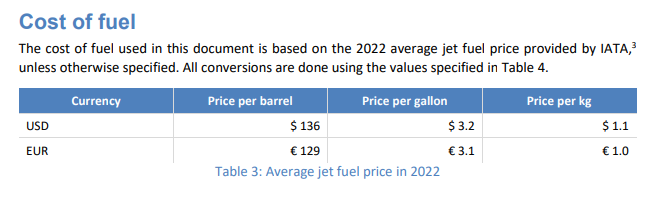

In [151]:
# Define cost function
def cost(air_craft,distance_km):
  ca = 624,892 # from https://www.afraa.org/wp-content/uploads/2024/08/2020-Report-Taxes-fees-and-charges-study.pdf
  try:
    estimated_seats_= int(estimated_seats[estimated_seats['iata_code'].str.contains(air_craft, na=False)]["Seats_Estimated"])
    fuel_used_cost = 0.020*distance_km*estimated_seats_*1.1 + ca
  except:
    fuel_used_cost = np.nan

  return fuel_used_cost

#input:  fuel_used('M82 EM2 DC9',25)

#output: {'M82': 900.0, 'EM2': 61.875, 'DC9': 0}

In [168]:
cost('EM2	',4068)

nan

In [169]:
fuel_cost_by_equipement('77L',4068)

NameError: name 'fuel_cost_by_equipement' is not defined

# **12. Cost modeling function**

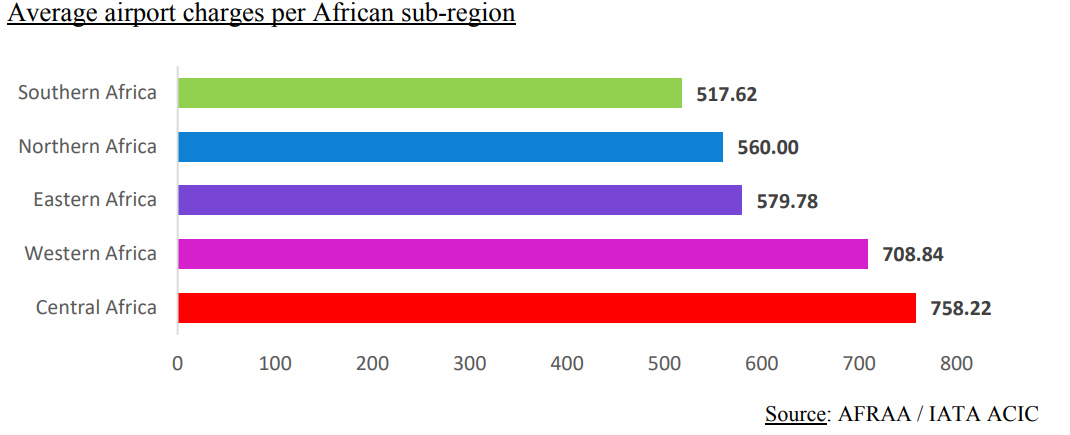

## **12.1 Computing route distance**

In [170]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


In [171]:
african_routes["distance_km"] = haversine(
    african_routes["source_lat"],
    african_routes["source_lon"],
    african_routes["dest_lat"],
    african_routes["dest_lon"]
)

In [172]:
african_routes["distance_km"].max()

6716.693576451293

In [173]:
african_routes[["source_airport", "destination_airport", "distance_km"]].head()

,source_airport,destination_airport,distance_km
0,ACC,OUA,764.743592
1,BKO,DKR,1059.572897
2,BKO,OUA,699.274661
3,BOY,OUA,334.279425
4,COO,LFW,126.687600


In [174]:
G = nx.DiGraph()

for _, row in african_routes.iterrows():
    G.add_edge(
        row["source_airport"],
        row["destination_airport"],
        weight=row["distance_km"]
    )

In [175]:
print("Number of nodes :", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes : 283
Number of edges: 1264


In [176]:
#
africa_map = folium.Map(
    location=[0, 20],
    zoom_start=3,
    tiles="cartodbpositron"
)

In [177]:
#
for _, row in african_routes.iterrows():
    folium.PolyLine(
        locations=[
            (row["source_lat"], row["source_lon"]),
            (row["dest_lat"], row["dest_lon"])
        ],
        color="blue",
        weight=1,
        opacity=0.4
    ).add_to(africa_map)


In [178]:
#
african_airports = african_airports[(african_airports['iata'].isin(african_routes['source_airport'])) | (african_airports['iata'].isin(african_routes['destination_airport']))]

In [179]:
for _, row in african_airports.iterrows():
    folium.CircleMarker(
        location=(row["latitude"], row["longitude"]),
        radius=2,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=f"{row['iata']} - {row['city']}"
    ).add_to(africa_map)


In [180]:
africa_map

# **13. Constraints available or computable**

In [181]:
african_routes

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment,source_lat,source_lon,source_country,source_city,dest_lat,dest_lon,dest_country,dest_city,distance_km,source_out_degree,destination_in_degree
0,2J,470,ACC,248.0,OUA,246.0,NaN,0,CRJ,5.60519,-0.166786,Ghana,Accra,12.353200,-1.512420,Burkina Faso,Ouagadougou,764.743592,35,20.0
1,2J,470,BKO,1044.0,DKR,1084.0,NaN,0,M87,12.53350,-7.949940,Mali,Bamako,14.739700,-17.490200,Senegal,Dakar,1059.572897,22,38.0
2,2J,470,BKO,1044.0,OUA,246.0,NaN,0,CRJ,12.53350,-7.949940,Mali,Bamako,12.353200,-1.512420,Burkina Faso,Ouagadougou,699.274661,22,20.0
3,2J,470,BOY,247.0,OUA,246.0,NaN,0,CRJ,11.16010,-4.330970,Burkina Faso,Bobo-dioulasso,12.353200,-1.512420,Burkina Faso,Ouagadougou,334.279425,1,20.0
4,2J,470,COO,245.0,LFW,298.0,NaN,0,M87,6.35723,2.384350,Benin,Cotonou,6.165610,1.254510,Togo,Lome,126.687600,32,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1923,XU,\N,NBO,4059.0,EBB,1187.0,NaN,0,M82,-1.31924,36.927799,Kenya,Nairobi,0.042386,32.443501,Uganda,Entebbe,521.070285,87,21.0
1924,XU,\N,NBO,4059.0,GLK,5688.0,NaN,0,EM2,-1.31924,36.927799,Kenya,Nairobi,6.780830,47.454700,Somalia,Galcaio,1475.121140,87,4.0
1925,XU,\N,NBO,4059.0,HGA,1121.0,NaN,0,EM2,-1.31924,36.927799,Kenya,Nairobi,9.518170,44.088799,Somalia,Hargeisa,1442.590267,87,7.0
1926,XU,\N,NBO,4059.0,MGQ,5687.0,NaN,0,M82 DC9,-1.31924,36.927799,Kenya,Nairobi,2.014440,45.304699,Somalia,Mogadishu,1002.380653,87,10.0


## **13.1 Operating cost**

In [182]:
out_degree = african_routes["source_airport"].value_counts()
african_routes["source_out_degree"] = african_routes["source_airport"].map(out_degree)

In [183]:
in_degree = african_routes["destination_airport"].value_counts()
african_routes["destination_in_degree"] = african_routes["destination_airport"].map(out_degree)
african_routes["destination_in_degree"] = african_routes["destination_in_degree"].fillna(0)

In [184]:
african_routes["international"] = (
    african_routes["source_country"] != african_routes["dest_country"]
).astype(int)


In [185]:
african_routes

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment,source_lat,...,source_country,source_city,dest_lat,dest_lon,dest_country,dest_city,distance_km,source_out_degree,destination_in_degree,international
0,2J,470,ACC,248.0,OUA,246.0,NaN,0,CRJ,5.60519,...,Ghana,Accra,12.353200,-1.512420,Burkina Faso,Ouagadougou,764.743592,35,20.0,1
1,2J,470,BKO,1044.0,DKR,1084.0,NaN,0,M87,12.53350,...,Mali,Bamako,14.739700,-17.490200,Senegal,Dakar,1059.572897,22,38.0,1
2,2J,470,BKO,1044.0,OUA,246.0,NaN,0,CRJ,12.53350,...,Mali,Bamako,12.353200,-1.512420,Burkina Faso,Ouagadougou,699.274661,22,20.0,1
3,2J,470,BOY,247.0,OUA,246.0,NaN,0,CRJ,11.16010,...,Burkina Faso,Bobo-dioulasso,12.353200,-1.512420,Burkina Faso,Ouagadougou,334.279425,1,20.0,0
4,2J,470,COO,245.0,LFW,298.0,NaN,0,M87,6.35723,...,Benin,Cotonou,6.165610,1.254510,Togo,Lome,126.687600,32,13.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1923,XU,\N,NBO,4059.0,EBB,1187.0,NaN,0,M82,-1.31924,...,Kenya,Nairobi,0.042386,32.443501,Uganda,Entebbe,521.070285,87,21.0,1
1924,XU,\N,NBO,4059.0,GLK,5688.0,NaN,0,EM2,-1.31924,...,Kenya,Nairobi,6.780830,47.454700,Somalia,Galcaio,1475.121140,87,4.0,1
1925,XU,\N,NBO,4059.0,HGA,1121.0,NaN,0,EM2,-1.31924,...,Kenya,Nairobi,9.518170,44.088799,Somalia,Hargeisa,1442.590267,87,7.0,1
1926,XU,\N,NBO,4059.0,MGQ,5687.0,NaN,0,M82 DC9,-1.31924,...,Kenya,Nairobi,2.014440,45.304699,Somalia,Mogadishu,1002.380653,87,10.0,1


# **14. Optimization model setup**

In [186]:
G = nx.DiGraph()

for _, row in african_routes.iterrows():
    G.add_edge(
        row["source_airport"],
        row["destination_airport"],
        weight=row["distance_km"]
    )

In [187]:
pagerank = nx.pagerank(G, alpha=0.85) # Alpha 0.85 as suggested by Brin and Page, 1999

african_routes["source_pagerank"] = african_routes["source_airport"].map(pagerank).fillna(0)
african_routes["dest_pagerank"] = african_routes["destination_airport"].map(pagerank).fillna(0)

In [188]:
gamma_values = np.linspace(0.01, 2, 100)
F_total = 3584 ## Mean: https://arxiv.org/pdf/2512.02075

for gamma in gamma_values:
    S = np.sum(
        (african_routes["source_pagerank"] * african_routes["dest_pagerank"]) / (african_routes["distance_km"] ** gamma)
    )

    K = F_total / S
    african_routes["D_eff"] = african_routes["distance_km"].clip(lower=african_routes['distance_km'].quantile(0.25))

    african_routes["F_hat"] = K * (
        african_routes["source_pagerank"] * african_routes["dest_pagerank"]
    ) / (african_routes["D_eff"] ** gamma)


    if abs(F_total - african_routes["F_hat"].sum()) <= 10:
      print(african_routes["F_hat"].sum(), "K:", K, "gamma:", gamma)
      break

african_routes["F_hat"].sum()

3582.8755161180525 K: 11758.042433425604 gamma: 0.01


np.float64(3582.8755161180525)

In [189]:
african_routes.sort_values(by="F_hat", ascending=False).head(30).iloc[:,:15]

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment,source_lat,source_lon,source_country,source_city,dest_lat,dest_lon
606,ET,2220,ADD,1107.0,JNB,813.0,NaN,0,77L,8.977890,38.799301,Ethiopia,Addis Ababa,-26.139200,28.246000
691,ET,2220,JNB,813.0,ADD,1107.0,NaN,0,77L,-26.139200,28.246000,South Africa,Johannesburg,8.977890,38.799301
1452,SA,4305,JNB,813.0,ADD,1107.0,Y,0,77L,-26.139200,28.246000,South Africa,Johannesburg,8.977890,38.799301
1393,SA,4305,ADD,1107.0,JNB,813.0,Y,0,77L,8.977890,38.799301,Ethiopia,Addis Ababa,-26.139200,28.246000
924,KQ,3126,JNB,813.0,NBO,4059.0,NaN,0,738 763 73W,-26.139200,28.246000,South Africa,Johannesburg,-1.319240,36.927799
965,KQ,3126,NBO,4059.0,JNB,813.0,NaN,0,738 763 73W,-1.319240,36.927799,Kenya,Nairobi,-26.139200,28.246000
1486,SA,4305,JNB,813.0,NBO,4059.0,NaN,0,320 319,-26.139200,28.246000,South Africa,Johannesburg,-1.319240,36.927799
1526,SA,4305,NBO,4059.0,JNB,813.0,NaN,0,319 320,-1.319240,36.927799,Kenya,Nairobi,-26.139200,28.246000
846,KL,3090,ADD,1107.0,NBO,4059.0,Y,0,E90,8.977890,38.799301,Ethiopia,Addis Ababa,-1.319240,36.927799
950,KQ,3126,NBO,4059.0,ADD,1107.0,NaN,0,E90,-1.319240,36.927799,Kenya,Nairobi,8.977890,38.799301


## **14.1 Demand proxy: $\alpha=1$ and $\beta=0.002$**

In [190]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

african_routes["source_pagerank_norm"] = minmax(african_routes["source_pagerank"])
african_routes["dest_pagerank_norm"] = minmax(african_routes["dest_pagerank"])

In [191]:
alpha = 1
beta = 0.0001

In [192]:
african_routes['demand_raw'] = alpha * african_routes['source_pagerank_norm'] * african_routes['dest_pagerank_norm'] * np.exp(-beta * african_routes['distance_km'])

In [193]:
african_routes['demand_raw']

,demand_raw
0,0.048490
1,0.062447
2,0.038159
3,0.000481
4,0.020275
...,...
1923,0.108067
1924,0.022805
1925,0.041265
1926,0.069171


In [194]:
african_routes.sort_values(by="demand_raw", ascending=False)['demand_raw']

,demand_raw
737,0.661934
871,0.661934
950,0.661934
1281,0.661934
846,0.661881
...,...
505,0.000003
316,0.000000
804,0.000000
436,0.000000


In [195]:
alpha = F_total / african_routes["demand_raw"].sum()
african_routes["demand"] = alpha * african_routes["demand_raw"]


In [196]:
african_routes.sort_values(by="demand", ascending=False)['demand']

,demand
737,28.888524
871,28.888524
950,28.888524
1281,28.888524
846,28.886215
...,...
505,0.000124
316,0.000000
804,0.000000
436,0.000000


## **14.2 Revenue model: $\rho=200$**

In [197]:
rho = 200

In [198]:
african_routes['revenue'] = rho * african_routes['demand'] * african_routes['F_hat']

In [199]:
african_routes.sort_values(by="revenue", ascending=False)['revenue']

,revenue
1393,164849.216855
606,164849.216855
691,164844.577225
1452,164844.577225
950,141025.646533
...,...
505,0.000113
804,0.000000
316,0.000000
1768,0.000000


In [200]:
estimated_seats

,iata_code,icao_code,manufacturer_and_aircraft_type_model,wtc,Seats_Estimated
0,100,F100,Fokker 100,M,100.0
1,141,B461,BAe 146-100 Pax,M,90.0
2,142,B462,BAe 146-200 Pax,M,90.0
3,143,B463,BAe 146-300 Pax,M,120.0
4,146,NaN,BAe 146 all pax models,M,NaN
...,...,...,...,...,...
394,YK2,YK42,Yakovlev Yak 42,M,NaN
395,YK4,YK40,Yakovlev Yak 40,M,NaN
396,YN2,Y12,Harbin Yunshuji Y12,M,NaN
397,YN7,AN24,Xian Yunshuji Y7,M,NaN


In [201]:
african_routes.merge(estimated_seats, left_on='source_airport', right_on='iata_code', how='inner')

,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment,source_lat,...,source_pagerank_norm,dest_pagerank_norm,demand_raw,demand,revenue,iata_code,icao_code,manufacturer_and_aircraft_type_model,wtc,Seats_Estimated
0,JE,3393,GRJ,804.0,JNB,813.0,NaN,0,738 733,-34.005600,...,0.021118,1.000000,0.019031,0.830576,167.212666,GRJ,NaN,Gulfstream Aerospace G-1159 Gulfstream II / II...,M,NaN
1,MN,1829,GRJ,804.0,JNB,813.0,NaN,0,738,-34.005600,...,0.021118,1.000000,0.019031,0.830576,167.212666,GRJ,NaN,Gulfstream Aerospace G-1159 Gulfstream II / II...,M,NaN
2,SA,4305,GRJ,804.0,CPT,797.0,Y,0,CR2 ER3 AR8,-34.005600,...,0.021118,0.264876,0.005402,0.235769,13.052587,GRJ,NaN,Gulfstream Aerospace G-1159 Gulfstream II / II...,M,NaN
3,SA,4305,GRJ,804.0,DUR,799.0,Y,0,ER3,-34.005600,...,0.021118,0.113721,0.002182,0.095228,2.356000,GRJ,NaN,Gulfstream Aerospace G-1159 Gulfstream II / II...,M,NaN
4,SA,4305,GRJ,804.0,JNB,813.0,NaN,0,738 733,-34.005600,...,0.021118,1.000000,0.019031,0.830576,167.212666,GRJ,NaN,Gulfstream Aerospace G-1159 Gulfstream II / II...,M,NaN
5,W3,20976,ABB,NaN,ABV,260.0,NaN,0,73G,6.204167,...,0.006369,0.213772,0.001319,0.057557,1.361665,ABB,A3ST,Airbus Industrie A300-600ST Beluga Freighter,H,NaN
6,W3,20976,ABB,NaN,LOS,273.0,NaN,0,73G,6.204167,...,0.006369,0.339075,0.002081,0.090808,3.349459,ABB,A3ST,Airbus Industrie A300-600ST Beluga Freighter,H,NaN
7,W3,20976,BNI,262.0,ABV,260.0,NaN,0,CR9 73G,6.316980,...,0.005824,0.213772,0.001202,0.052464,1.199661,BNI,BN2P,Pilatus Britten-Norman BN-2A/B Islander,L,NaN
8,W3,20976,BNI,262.0,LOS,273.0,NaN,0,73G,6.316980,...,0.005824,0.339075,0.001925,0.084030,2.995777,BNI,BN2P,Pilatus Britten-Norman BN-2A/B Islander,L,NaN


In [202]:
african_routes['connectivity'] = african_routes['source_out_degree'] + african_routes['destination_in_degree']

In [203]:
african_routes['connectivity'] = minmax(african_routes['connectivity'])
african_routes['hub'] = african_routes['source_pagerank'] + african_routes['dest_pagerank']

african_routes['hub'] = minmax(african_routes['hub'])

In [204]:
african_routes['equipment'] = african_routes['equipment'].fillna('Unknown').astype(str)

african_routes['equipment'] = african_routes['equipment'].str.split(' ')

african_routes_per_equipment = african_routes.explode('equipment')

african_routes_per_equipment['equipment'] = african_routes_per_equipment['equipment'].str.strip("{}")

In [205]:
african_routes_per_equipment['equipment'] = (
    african_routes_per_equipment['equipment']
    .astype(str)
    .str.replace(r"[\[\]'\" ]", "", regex=True)
)

african_routes_per_equipment['equipment'] = african_routes_per_equipment['equipment'].str.split(',')

african_routes_per_equipment = african_routes_per_equipment.explode('equipment')

african_routes_per_equipment = african_routes_per_equipment[african_routes_per_equipment['equipment'] != ""]

In [206]:
african_routes_per_equipment = african_routes_per_equipment.merge(estimated_seats, left_on='equipment', right_on='iata_code', how='left')

In [207]:
african_routes_per_equipment.dropna(subset=['source_airport_id', 'destination_airport_id'], inplace=True)

In [208]:
median_value = african_routes_per_equipment['Seats_Estimated'].median()

african_routes_per_equipment['Seats_Estimated'] = african_routes_per_equipment['Seats_Estimated'].fillna(median_value)

In [209]:
def calculate_route_cost(row):
    ca = 624.892

    air_craft = str(row['equipment'])
    distance_km = row['distance_km']
    seat_mean = estimated_seats["Seats_Estimated"].mean()

    try:
        mask = estimated_seats['iata_code'].str.contains(air_craft, na=False)
        seats = int(estimated_seats.loc[mask, "Seats_Estimated"].iloc[0])

        fuel_used_cost = (0.020 * distance_km * seats * 1.1) + ca
        return fuel_used_cost
    except:
        return (0.020 * distance_km * seat_mean * 1.1) + ca

african_routes_per_equipment['cost'] = african_routes_per_equipment.apply(calculate_route_cost, axis=1)

In [210]:
def calculate_route_cost(row):
    """
    Calculates the cost of an airline route based on fuel consumption.

    Parameters:
    row : pandas.Series
        A row from the DataFrame containing route information
        Must contain: 'equipment' (aircraft type) and 'distance_km' (distance in km)

    Returns:
    ---------
    float : Total route cost in currency units

    Cost Formula:
    ----------------
    cost = (0.020 × distance_km × number_of_seats × 1.1) + fixed_cost
    where:
    - 0.020 : unit fuel cost per km per seat
    - 1.1 : markup factor (10% margin)
    - 624.892 : fixed cost per flight (base operating expenses)
    """

    # Fixed cost per flight (operating expenses, personnel, base maintenance, etc.)
    FIXED_COST = 624.892

    # Variable fuel cost per km per seat
    FUEL_COST_PER_KM_SEAT = 0.020

    # Markup factor (10% operating margin)
    MARKUP_FACTOR = 1.1

    # Extract route data
    aircraft_code = str(row['equipment'])
    distance_km = row['distance_km']

    # Calculate average number of seats (used as default value)
    seat_mean = estimated_seats["Seats_Estimated"].mean()

    try:
        # Search for the number of seats for the specific aircraft type
        mask = estimated_seats['iata_code'].str.contains(aircraft_code, na=False)
        seats = int(estimated_seats.loc[mask, "Seats_Estimated"].iloc[0])

        # Calculate total cost with specific number of seats
        fuel_cost = (FUEL_COST_PER_KM_SEAT * distance_km * seats * MARKUP_FACTOR)
        total_cost = fuel_cost + FIXED_COST

        return total_cost

    except (IndexError, ValueError):
        # If aircraft not found, use average number of seats
        fuel_cost = (FUEL_COST_PER_KM_SEAT * distance_km * seat_mean * MARKUP_FACTOR)
        total_cost = fuel_cost + FIXED_COST

        return total_cost


# Apply the function to all routes
african_routes_per_equipment['cost'] = african_routes_per_equipment.apply(
    calculate_route_cost,
    axis=1
)

In [211]:
african_routes_per_equipment.columns

Index(['airline', 'airline_id', 'source_airport', 'source_airport_id',
       'destination_airport', 'destination_airport_id', 'codeshare', 'stops',
       'equipment', 'source_lat', 'source_lon', 'source_country',
       'source_city', 'dest_lat', 'dest_lon', 'dest_country', 'dest_city',
       'distance_km', 'source_out_degree', 'destination_in_degree',
       'international', 'source_pagerank', 'dest_pagerank', 'D_eff', 'F_hat',
       'source_pagerank_norm', 'dest_pagerank_norm', 'demand_raw', 'demand',
       'revenue', 'connectivity', 'hub', 'iata_code', 'icao_code',
       'manufacturer_and_aircraft_type_model', 'wtc', 'Seats_Estimated',
       'cost'],
      dtype='object')

In [212]:
row

,1927
airline,XU
airline_id,\N
source_airport,WJR
source_airport_id,1149.0
destination_airport,NBO
destination_airport_id,4059.0
codeshare,NaN
stops,0
equipment,M82 EM2 DC9
source_lat,1.73324


# **15. Optimization of the African airline network**

We now formulate the final optimization model.  
The model uses:

- a **binary activation variable** for each route,
- an **integer weekly frequency variable**,
- an objective combining **estimated profit** and **strategic connectivity/hub bonuses**,
- and frequency bounds that link route activation to operational use.

This section produces the final optimized route plan used later for visualization.

In [213]:
prob = pulp.LpProblem("African_Route_Optimization", pulp.LpMaximize)
routes_idx = african_routes_per_equipment.index

# Variables
x = pulp.LpVariable.dicts("route_active", routes_idx, cat='Binary')
freq = pulp.LpVariable.dicts("frequency", routes_idx, lowBound=0, upBound=100, cat='Integer')

# Big M : maximum de vols autorisés par route
M = 30

for i in routes_idx:
    prob += freq[i] <= M * x[i]

    prob += freq[i] >= x[i]

# Objectif
hub_weight = 1000

prob += pulp.lpSum([
    # Profit (Revenu - Coût)
    (african_routes_per_equipment.loc[i, 'revenue'] * freq[i]) -
    (african_routes_per_equipment.loc[i, 'cost'] * freq[i]) +

    # Bonus Connectivité générale
    (500 * african_routes_per_equipment.loc[i, 'connectivity'] * x[i]) +

    # BONUS HUB : On valorise l'ouverture de routes vers/depuis des hubs
    (hub_weight * african_routes_per_equipment.loc[i, 'hub'] * x[i])

    for i in routes_idx
])

total_opened = pulp.lpSum([x[i] for i in routes_idx])
total_hub_score = pulp.lpSum([african_routes_per_equipment.loc[i, 'hub'] * x[i] for i in routes_idx])

# Contrainte : Total des scores >= 0.4 * Nombre de routes ouvertes
prob += total_hub_score >= 0.4 * total_opened

status = prob.solve()
print(f"Status: {pulp.LpStatus[status]}")

if status == pulp.LpStatusOptimal:
    print("Optimal solution found!")

Status: Optimal
Optimal solution found!


## **15.1 Extraction of the optimized flight plan**

Once the optimization problem is solved, we extract the active routes and summarize them in a structured table containing:

- source and destination cities,
- aircraft/equipment,
- optimized weekly frequency,
- route distance,
- estimated revenue,
- connectivity score.

This table is the main bridge between the optimization model and the final visualization.

In [214]:
results = []

for i in routes_idx:
    # On récupère la valeur de la variable binaire (x) et de la fréquence (f)
    # pulp.value() permet d'accéder au résultat numérique
    is_active = pulp.value(x[i])
    flights_count = pulp.value(freq[i])

    if is_active:
        results.append({
            'Source': african_routes_per_equipment.loc[i, 'source_city'],
            'Destination': african_routes_per_equipment.loc[i, 'dest_city'],
            'Equipment': african_routes_per_equipment.loc[i, 'equipment'],
            'Frequency_Per_Week': flights_count,
            'Distance_KM': african_routes_per_equipment.loc[i, 'distance_km'],
            'Revenue_Estimated': african_routes_per_equipment.loc[i, 'revenue'] * flights_count,
            'Connectivity_Score': african_routes_per_equipment.loc[i, 'connectivity']
        })


df_plan_de_vol = pd.DataFrame(results)

# Result
print(f"Nombre de routes ouvertes : {len(df_plan_de_vol)}")
print(f"Profit Total : {pulp.value(prob.objective):,.2f} USD")
print("-" * 30)
df_plan_de_vol.sort_values(by='Frequency_Per_Week', ascending=False).head(10)

Nombre de routes ouvertes : 425
Profit Total : 165,902,289.76 USD
------------------------------


,Source,Destination,Equipment,Frequency_Per_Week,Distance_KM,Revenue_Estimated,Connectivity_Score
424,Wajir,Nairobi,EM2,30.0,488.812246,35363.788962,0.471503
0,Accra,Lagos,319,30.0,400.511356,91577.448547,0.373057
1,Lagos,Accra,319,30.0,400.511356,91563.956545,0.373057
422,Nairobi,Entebbe,M82,30.0,521.070285,113037.551494,0.554404
421,Entebbe,Nairobi,M82,30.0,521.070285,113306.292248,0.554404
4,Nairobi,Kigali,E70,30.0,757.956774,117653.925296,0.637306
382,Maputo,Johannesburg,E90,30.0,432.957197,321712.256754,0.632124
383,Maputo,Johannesburg,E90,30.0,432.957197,321712.256754,0.632124
384,Maputo,Johannesburg,ER4,30.0,432.957197,321712.256754,0.632124
385,Maputo,Johannesburg,735,30.0,432.957197,321712.256754,0.632124


# **16. Final interactive visualization of the optimized African air network**

The last code cell builds an interactive African map using the optimized routes computed above.

It shows:

- the **selected air routes**,
- the **weekly flight frequency** through line thickness and color,
- the **most solicited airports** through marker size,
- and summary tables for the most important optimized routes and airports.

This is the final visual synthesis of the notebook.

In [215]:
# ============================================================
# Visualisation du transport aérien optimisé en Afrique
# Cette cellule utilise les résultats d'optimisation obtenus plus haut
# et construit une carte interactive cohérente avec les analyses précédentes.
# ============================================================

import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster

# ------------------------------------------------------------
# 1) Reconstruire un tableau géographique des routes optimisées
# ------------------------------------------------------------
viz_rows = []

try:
    for i in routes_idx:
        is_active = pulp.value(x[i])
        flights_count = pulp.value(freq[i])

        if is_active is not None and flights_count is not None and flights_count > 0:
            row = african_routes_per_equipment.loc[i]

            viz_rows.append({
                "source_airport": row["source_airport"],
                "destination_airport": row["destination_airport"],
                "Source": row["source_city"],
                "Destination": row["dest_city"],
                "source_country": row.get("source_country", ""),
                "dest_country": row.get("dest_country", ""),
                "Equipment": row["equipment"],
                "Frequency_Per_Week": float(flights_count),
                "Distance_KM": float(row["distance_km"]),
                "Revenue_Estimated": float(row.get("revenue", 0) * flights_count),
                "Connectivity_Score": float(row.get("connectivity", 0)),
                "source_lat": float(row["source_lat"]),
                "source_lon": float(row["source_lon"]),
                "dest_lat": float(row["dest_lat"]),
                "dest_lon": float(row["dest_lon"]),
            })

    optimized_routes_geo = pd.DataFrame(viz_rows)

except Exception as e:
    print("Reconstruction directe impossible à partir des variables d'optimisation :", e)
    optimized_routes_geo = pd.DataFrame()

# Fallback : si besoin, on repart de df_plan_de_vol et on récupère les coordonnées
if optimized_routes_geo.empty and "df_plan_de_vol" in globals():
    optimized_routes_geo = df_plan_de_vol.merge(
        african_routes_per_equipment[[
            "source_city", "dest_city", "equipment", "distance_km",
            "source_airport", "destination_airport",
            "source_country", "dest_country",
            "source_lat", "source_lon", "dest_lat", "dest_lon"
        ]].drop_duplicates(),
        left_on=["Source", "Destination", "Equipment", "Distance_KM"],
        right_on=["source_city", "dest_city", "equipment", "distance_km"],
        how="left"
    ).rename(columns={
        "source_city": "Source",
        "dest_city": "Destination",
        "equipment": "Equipment"
    })

if optimized_routes_geo.empty:
    raise ValueError(
        "Aucune route optimisée n'a été trouvée. "
        "Exécutez d'abord les cellules d'optimisation avant cette visualisation."
    )

# Nettoyage / sécurité
optimized_routes_geo = optimized_routes_geo.dropna(subset=[
    "source_lat", "source_lon", "dest_lat", "dest_lon", "Frequency_Per_Week"
]).copy()

optimized_routes_geo["Frequency_Per_Week"] = pd.to_numeric(
    optimized_routes_geo["Frequency_Per_Week"], errors="coerce"
).fillna(0)

optimized_routes_geo = optimized_routes_geo[optimized_routes_geo["Frequency_Per_Week"] > 0].copy()

# ------------------------------------------------------------
# 2) Créer un indicateur d'activité des aéroports
# ------------------------------------------------------------
airport_out = optimized_routes_geo.groupby(
    ["source_airport", "Source", "source_country", "source_lat", "source_lon"],
    dropna=False
)["Frequency_Per_Week"].sum().reset_index().rename(columns={
    "source_airport": "Airport",
    "Source": "City",
    "source_country": "Country",
    "source_lat": "Latitude",
    "source_lon": "Longitude",
    "Frequency_Per_Week": "Weekly_Flights_Out"
})

airport_in = optimized_routes_geo.groupby(
    ["destination_airport", "Destination", "dest_country", "dest_lat", "dest_lon"],
    dropna=False
)["Frequency_Per_Week"].sum().reset_index().rename(columns={
    "destination_airport": "Airport",
    "Destination": "City",
    "dest_country": "Country",
    "dest_lat": "Latitude",
    "dest_lon": "Longitude",
    "Frequency_Per_Week": "Weekly_Flights_In"
})

airport_activity = airport_out.merge(
    airport_in,
    on=["Airport", "City", "Country", "Latitude", "Longitude"],
    how="outer"
).fillna(0)

airport_activity["Total_Weekly_Flights"] = (
    airport_activity["Weekly_Flights_Out"] + airport_activity["Weekly_Flights_In"]
)

# ------------------------------------------------------------
# 3) Fonctions de style
# ------------------------------------------------------------
freq_min = optimized_routes_geo["Frequency_Per_Week"].min()
freq_max = optimized_routes_geo["Frequency_Per_Week"].max()

def route_weight(freq):
    if freq_max == freq_min:
        return 4
    return 2 + 6 * (freq - freq_min) / (freq_max - freq_min)

def route_color(freq):
    if freq >= 20:
        return "#d73027"   # rouge
    elif freq >= 8:
        return "#fc8d59"   # orange
    else:
        return "#4575b4"   # bleu

def airport_radius(total_flights):
    if airport_activity["Total_Weekly_Flights"].max() == 0:
        return 5
    return 4 + 12 * total_flights / airport_activity["Total_Weekly_Flights"].max()

# ------------------------------------------------------------
# 4) Construire la carte interactive
# ------------------------------------------------------------
center_lat = airport_activity["Latitude"].mean()
center_lon = airport_activity["Longitude"].mean()

africa_optimized_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=4,
    tiles="CartoDB positron"
)

routes_layer = folium.FeatureGroup(name="Optimized routes", show=True)
airports_layer = folium.FeatureGroup(name="Strategic airports", show=True)

# Tracer les routes optimisées
for _, row in optimized_routes_geo.iterrows():
    tooltip_text = (
        f"<b>{row['Source']} ({row['source_airport']}) → {row['Destination']} ({row['destination_airport']})</b><br>"
        f"Aircraft: {row['Equipment']}<br>"
        f"Flights/week: {row['Frequency_Per_Week']:.0f}<br>"
        f"Distance: {row['Distance_KM']:.0f} km<br>"
        f"Estimated revenue: {row.get('Revenue_Estimated', 0):,.0f}<br>"
        f"Connectivity score: {row.get('Connectivity_Score', 0):.3f}"
    )

    folium.PolyLine(
        locations=[(row["source_lat"], row["source_lon"]), (row["dest_lat"], row["dest_lon"])],
        color=route_color(row["Frequency_Per_Week"]),
        weight=route_weight(row["Frequency_Per_Week"]),
        opacity=0.75,
        tooltip=folium.Tooltip(tooltip_text, sticky=True)
    ).add_to(routes_layer)

# Ajouter les aéroports clés
marker_cluster = MarkerCluster(name="Airport clusters").add_to(airports_layer)

for _, row in airport_activity.iterrows():
    popup_text = (
        f"<b>{row['City']} ({row['Airport']})</b><br>"
        f"Country: {row['Country']}<br>"
        f"Outgoing flights/week: {row['Weekly_Flights_Out']:.0f}<br>"
        f"Incoming flights/week: {row['Weekly_Flights_In']:.0f}<br>"
        f"Total weekly traffic: {row['Total_Weekly_Flights']:.0f}"
    )

    folium.CircleMarker(
        location=(row["Latitude"], row["Longitude"]),
        radius=airport_radius(row["Total_Weekly_Flights"]),
        color="#1a9850",
        fill=True,
        fill_color="#1a9850",
        fill_opacity=0.8,
        weight=1,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{row['City']} ({row['Airport']})"
    ).add_to(marker_cluster)

routes_layer.add_to(africa_optimized_map)
airports_layer.add_to(africa_optimized_map)

# ------------------------------------------------------------
# 5) Légende
# ------------------------------------------------------------
legend_html = """
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 270px; z-index:9999;
    background-color: white; border:2px solid #444; border-radius:8px;
    padding: 12px; font-size: 13px; box-shadow: 2px 2px 8px rgba(0,0,0,0.25);
">
<b>Optimized African Air Network</b><br><br>
<b>Route color</b><br>
<span style="color:#d73027;">&#9632;</span> High frequency (≥ 20 flights/week)<br>
<span style="color:#fc8d59;">&#9632;</span> Medium frequency (8–19 flights/week)<br>
<span style="color:#4575b4;">&#9632;</span> Low frequency (1–7 flights/week)<br><br>
<b>Airport marker size</b><br>
Proportional to total weekly traffic<br>
(incoming + outgoing optimized flights)
</div>
"""
africa_optimized_map.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(africa_optimized_map)

# ------------------------------------------------------------
# 6) Sauvegarde + résumé numérique
# ------------------------------------------------------------
output_html = "transport_aerien_optimise_afrique.html"
africa_optimized_map.save(output_html)

top_routes = optimized_routes_geo.sort_values(
    by=["Frequency_Per_Week", "Revenue_Estimated"],
    ascending=False
)[[
    "Source", "Destination", "source_airport", "destination_airport",
    "Equipment", "Frequency_Per_Week", "Distance_KM", "Revenue_Estimated"
]].head(15)

top_airports = airport_activity.sort_values(
    by="Total_Weekly_Flights", ascending=False
)[[
    "City", "Airport", "Country", "Weekly_Flights_Out",
    "Weekly_Flights_In", "Total_Weekly_Flights"
]].head(15)

print("Carte enregistrée sous :", output_html)
print(f"Nombre total de routes optimisées visualisées : {len(optimized_routes_geo)}")
print(f"Nombre d'aéroports stratégiques impliqués : {airport_activity['Airport'].nunique()}")
print("-" * 70)
print("Top 15 des routes optimisées :")
display(top_routes)
print("-" * 70)
print("Top 15 des aéroports les plus sollicités :")
display(top_airports)

africa_optimized_map

Carte enregistrée sous : transport_aerien_optimise_afrique.html
Nombre total de routes optimisées visualisées : 425
Nombre d'aéroports stratégiques impliqués : 49
----------------------------------------------------------------------
Top 15 des routes optimisées :


,Source,Destination,source_airport,destination_airport,Equipment,Frequency_Per_Week,Distance_KM,Revenue_Estimated
70,Addis Ababa,Johannesburg,ADD,JNB,77L,30.0,4068.006696,4.945477e+06
219,Addis Ababa,Johannesburg,ADD,JNB,77L,30.0,4068.006696,4.945477e+06
81,Johannesburg,Addis Ababa,JNB,ADD,77L,30.0,4068.006696,4.945337e+06
255,Johannesburg,Addis Ababa,JNB,ADD,77L,30.0,4068.006696,4.945337e+06
89,Nairobi,Addis Ababa,NBO,ADD,738,30.0,1163.612619,4.230769e+06
90,Nairobi,Addis Ababa,NBO,ADD,763,30.0,1163.612619,4.230769e+06
117,Nairobi,Addis Ababa,NBO,ADD,EMJ,30.0,1163.612619,4.230769e+06
149,Nairobi,Addis Ababa,NBO,ADD,E90,30.0,1163.612619,4.230769e+06
150,Nairobi,Addis Ababa,NBO,ADD,E90,30.0,1163.612619,4.230769e+06
205,Nairobi,Addis Ababa,NBO,ADD,763,30.0,1163.612619,4.230769e+06


----------------------------------------------------------------------
Top 15 des aéroports les plus sollicités :


,City,Airport,Country,Weekly_Flights_Out,Weekly_Flights_In,Total_Weekly_Flights
23,Johannesburg,JNB,South Africa,2581.0,2611.0,5192.0
35,Nairobi,NBO,Kenya,1031.0,1120.0,2151.0
2,Addis Ababa,ADD,Ethiopia,639.0,518.0,1157.0
12,Cape Town,CPT,South Africa,570.0,570.0,1140.0
10,Casablanca,CMN,Morocco,390.0,481.0,871.0
47,Windhoek,WDH,Namibia,360.0,360.0,720.0
13,Dar Es Salaam,DAR,Tanzania,330.0,360.0,690.0
29,Lagos,LOS,Nigeria,331.0,271.0,602.0
9,Cairo,CAI,Egypt,300.0,300.0,600.0
15,Durban,DUR,South Africa,270.0,270.0,540.0


# **17. Concluding remarks**

This final notebook integrates the conceptual material from the two provided PDFs and the computational work already developed in Python.

In particular, it now contains:

- a **clear optimization context**,
- an **ordered computational workflow**,
- an **explicit optimization model**,
- a **structured extraction of results**, and
- a **final interactive visualization** of the optimized African airline network.

It can therefore be used both as a **working Jupyter notebook** and as a **clean support document** for presentation or reporting.